# analysis of x-ray ct scan

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tifffile as tif

In [2]:
octet_lattice = tif.imread("../data/9x9x9_octet_lattice/9x9x9_octet_lattice.tif")
octet_unit = np.load('../data/unitcell/unitcell.npy')
print('octet_lattice.shape:', octet_lattice.shape)
print('octet_unit.shape:', octet_unit.shape)

octet_lattice.shape: (761, 815, 837)
octet_unit.shape: (256, 256, 256)


[]

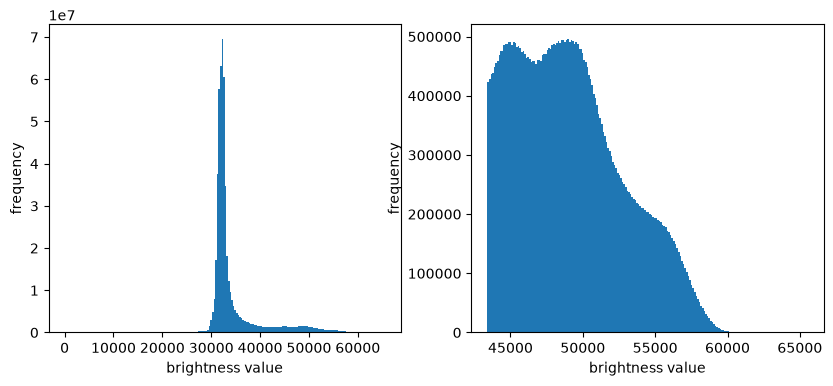

In [3]:
NOISE_THRESH = 43_400
fig, ax = plt.subplots(1, 2, figsize=(10,4))
ax[0].hist(octet_lattice.flatten(), bins=200)
ax[0].set_ylabel('frequency')
ax[0].set_xlabel('brightness value')
plt.plot()

ax[1].hist(octet_lattice[octet_lattice > NOISE_THRESH].flatten(), bins=200)
ax[1].set_ylabel('frequency')
ax[1].set_xlabel('brightness value')
plt.plot()

In [4]:
# remove obvious noise (43.5k is estimate)
octet_lattice[octet_lattice < NOISE_THRESH] = 0
# normalize
octet_lattice = (octet_lattice - np.min(octet_lattice))
octet_lattice = octet_lattice / np.max(octet_lattice)

In [5]:
LOW_PASS_VAL = 61_000
slice_sums = np.sum(octet_lattice, axis=(1, 2))
wall_mask = slice_sums >= LOW_PASS_VAL

In [6]:
wall_removed_lattice = octet_lattice.copy()
wall_removed_lattice[wall_mask] = 0

/var/folders/y4/nhklz40x1hb1gltwcy71zms00000gn/T/ipykernel_63239/485252349.py:9: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax[1].legend()


[]

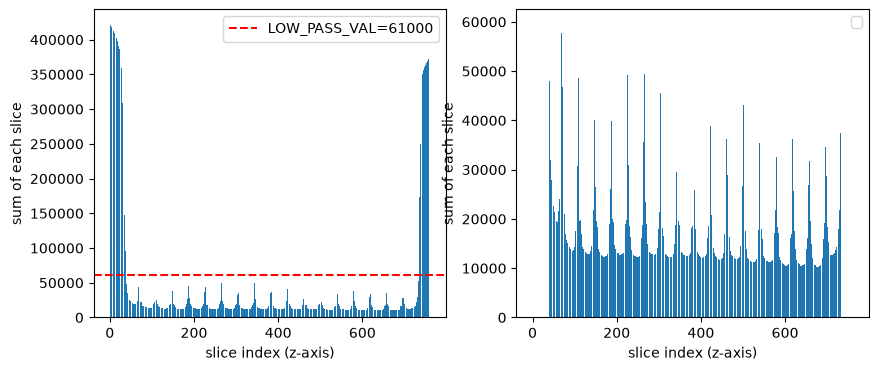

In [7]:
fig, ax = plt.subplots(1, 2, figsize=(10,4))
ax[0].bar(np.arange(octet_lattice.shape[0]), np.sum(octet_lattice, axis=(1, 2)))
ax[0].axhline(y=LOW_PASS_VAL, color='r', linestyle='--', label=f'LOW_PASS_VAL={LOW_PASS_VAL}')
ax[0].legend()
ax[0].set_xlabel('slice index (z-axis)')
ax[0].set_ylabel('sum of each slice')

ax[1].bar(np.arange(wall_removed_lattice.shape[0]), np.sum(wall_removed_lattice, axis=(1, 2)))
ax[1].legend()
ax[1].set_xlabel('slice index (z-axis)')
ax[1].set_ylabel('sum of each slice')
plt.plot()

(761,)
Found 18 dips
Dip indices: [ 59  95 131 169 208 251 290 324 364 403 447 483 526 561 601 638 676 711]
Dip values: [19359.64660105 13589.41704433 12836.13838407 12209.52498665
 12622.56295109 12252.56911574 12672.35616083 12209.08972305
 12358.44391547 11992.42812238 11706.43523308 11846.02043183
 11161.82159152 11280.95657282 10482.01042191 10422.83878843
 10207.77468528 12547.1853666 ]


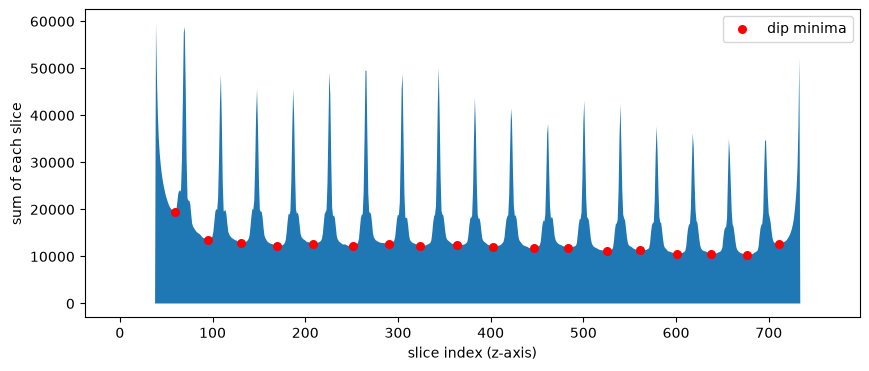

In [8]:
import numpy as np
from scipy.signal import find_peaks

fig, ax = plt.subplots(figsize=(10,4))

slice_sums = np.sum(wall_removed_lattice, axis=(1, 2))
print(slice_sums.shape)
ax.fill_between(np.arange(wall_removed_lattice.shape[0]), slice_sums)

# Find local minima by inverting the signal and finding peaks
# distance = minimum spacing between dips (adjust based on your peak spacing, ~35-40 here)
# prominence = how deep the dip must be to count (filters out tiny noise dips)
dip_indices, properties = find_peaks(-slice_sums, distance=20, prominence=2000)

# Mark the dips on the plot
ax.scatter(dip_indices, slice_sums[dip_indices], color='red', zorder=5, s=30, label='dip minima')

ax.set_xlabel('slice index (z-axis)')
ax.set_ylabel('sum of each slice')
ax.legend()

print(f"Found {len(dip_indices)} dips")
print(f"Dip indices: {dip_indices}")
print(f"Dip values: {slice_sums[dip_indices]}")

Rising edges (19): [ 38  68 107 146 186 225 264 303 342 382 421 460 499 539 578 617 656 695
 732]
Falling edges (19): [ 40  71 110 149 189 228 267 306 345 385 424 463 502 541 581 620 659 698
 734]


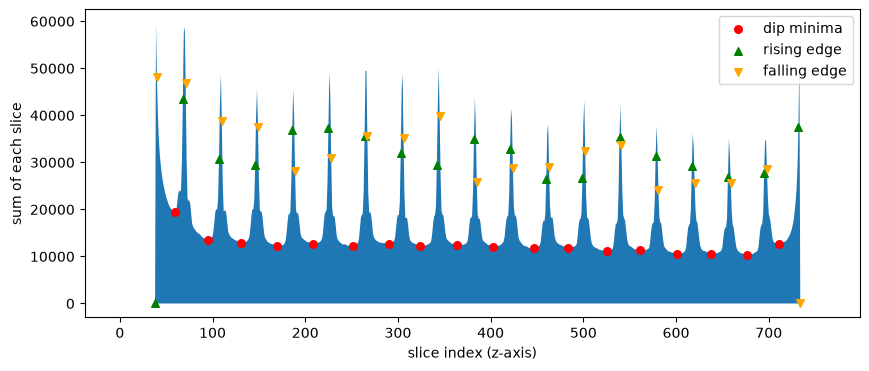

In [9]:
import numpy as np
from scipy.signal import find_peaks

fig, ax = plt.subplots(figsize=(10,4))

slice_sums = np.sum(wall_removed_lattice, axis=(1, 2))
ax.fill_between(np.arange(wall_removed_lattice.shape[0]), slice_sums)

# --- Existing dip detection ---
dip_indices, _ = find_peaks(-slice_sums, distance=20, prominence=2000)
ax.scatter(dip_indices, slice_sums[dip_indices], color='red', zorder=5, s=30, label='dip minima')

# --- New: detect sudden change points (steep rising/falling edges) ---
gradient = np.gradient(slice_sums)

# Find sharp rising edges (steep positive slope, going up into a peak)
rising_edges, _ = find_peaks(gradient, distance=10, prominence=1500)

# Find sharp falling edges (steep negative slope, coming down from a peak)
falling_edges, _ = find_peaks(-gradient, distance=10, prominence=1500)

ax.scatter(rising_edges, slice_sums[rising_edges], color='green', zorder=5, s=30, marker='^', label='rising edge')
ax.scatter(falling_edges, slice_sums[falling_edges], color='orange', zorder=5, s=30, marker='v', label='falling edge')

ax.set_xlabel('slice index (z-axis)')
ax.set_ylabel('sum of each slice')
ax.legend()

print(f"Rising edges ({len(rising_edges)}): {rising_edges}")
print(f"Falling edges ({len(falling_edges)}): {falling_edges}")

Animation saved to ./walled_removed_video.mp4


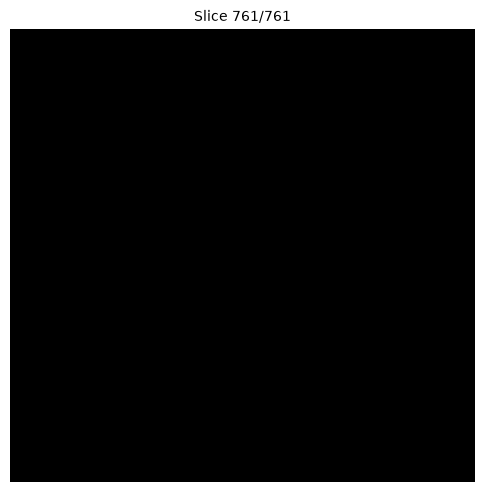

In [ ]:
from matplotlib.animation import FuncAnimation
from matplotlib.animation import FFMpegWriter

slice_axis = 0
n_slices = wall_removed_lattice.shape[slice_axis]
frame_indices = np.arange(n_slices)

fig_anim, ax_anim = plt.subplots(figsize=(6, 6))
img = ax_anim.imshow(
    wall_removed_lattice[0],
    cmap="gray",
    vmin=wall_removed_lattice.min(),
    vmax=wall_removed_lattice.max()
)
ax_anim.axis("off")

def update(frame):
    img.set_data(wall_removed_lattice[frame])
    ax_anim.set_title(f"Slice {frame + 1}/{n_slices}", fontsize=10)
    return (img,)

anim = FuncAnimation(
    fig_anim,
    update,
    frames=frame_indices,
    interval=100,
    blit=True,
)

output_path = "./walled_removed_video.mp4"
anim.save(output_path, writer=FFMpegWriter(fps=10))
print(f"Animation saved to {output_path}")